## D212 Task 2: Principal Component Analysis

Data Mining II - D212
<br> 
Clustering Techniques
<br> 
Instructor: Dr. Kesselly Kamara
<br> 
Student Name: Devon E. Johnson
<br> 
Student ID: 011494484
<br> 
Email: djo3593@wgu.edu
<br> 

### Table of Contents

* [A1: Research Question](#A1:-Research-Question)
* [A2: Analysis Goal](#A2:-Analysis-Goal)
* [B1: Principal Component Analysis](#B1:-Principle-Component-Analysis)
* [B2: Assumption](#B2:-Assumption)
* [C1: Variables](#C1:-Variables)
* [C2: Standardization](#C2:-Standardization)
* [D1: PCA Matrix](#D1:-PCA-Matrix)
* [D2: Total Principal Components](#D2:-Total-Principal-Components)
* [D3: Variance of each Component](#D3:-Variance-of-each-Component)
* [D4: Total Variance](#D4:-Total-Variance)
* [D5: Analysis Results](#D5:-Analysis-Results)
* [E1: Code References](#E1:-Code-References)
* [F1: Source References](#F1:-Source-References)

### A1: Research Question

I will investigate the following question: Considering population within a mile radius of the patient, primary insurance holder income, patient vitamin D levels, initial days spent in the hospital, average daily charges, and additional charges, are there any underlying patterns that can explain the variance in patient characteristics related to patient readmission?  

The modern healthcare system consistently struggles to support high patient volume and frequency effectively. Patient readmission has become an indicator of care quality and is often looked at by policymakers as a measure of healthcare efficacy across the board (Goldfield, 2011, p. E368). Understanding the underlying patterns in patient characteristics can help guide data-driven strategies to address such factors and reduce readmission rates.

### A2: Analysis Goal

The goal of this analysis is to reduce the complexity of the patient readmission dataset by consolidating seven correlated continuous variables into a smaller set of uncorrelated principal components. Additionally, there are existing multicollinearity concerns in our continuous data, particularly among initial hospital stay duration, estimated daily charges, and additional charges, and PCA will help eliminate these issues. Conducting PCA on the medical dataset will lay a foundation for future machine learning algorithms to identify patterns that predict patient readmission. 

### B1: Principle Component Analysis

Principal Component Analysis (PCA) is a dimensionality reduction technique that ultimately helps to mitigate issues later in the data cycle by reducing computational load and preventing overfitting (when a model includes too much noise and performs better on training data than on real-world data). This simplification helps in future data analysis and improves machine learning performance. 

PCA works by transforming the original variables, or dimensions, into a new set of "principal components." Each of these components is a linear combination of the original variables that captures the maximum possible variance, ordered from greatest to least. PCA leverages two main linear algebra concepts: eigenvalues and eigenvectors. Eigenvectors represent the directions of maximum variance while eigenvalues quantify the degree of that variance (Whitfield, 2025). Higher eigenvalues are more significant while lower eigenvalues account for less of the total variance ("Principal components (PCA) and exploratory factor analysis (EFA) with SPSS," n.d.).

In this case, PCA will be applied to the seven continuous variables identified in the research question to identify the minimum number of components that capture the majority of variance without oversacrificing information. Given that we are working with relatively few X variables for PCA, the degree of dimensionality reduction will depend on the data's correlation structure. PCA will perform better when the variables are highly correlated, and we will be able to achieve greater reduction while retaining a significant portion of the variance. On the other hand, if the variables are weakly correlated, we will have to keep more components to avoid information loss. I will check correlation in the next section. 

### B2: Assumption

Since PCA is based on the Pearson correlation coefficient, it assumes that is a linear relationship between all of the variables ("How to perform a principal components analysis (PCA) in SPSS statistics," n.d.). Linearity can be checked using a correlation matrix, with correlation levels of r ≥ 0.3 are generally considered adequate for inclusion ("Principal Component Analysis (PCA) - Assumptions," n.d.). As such, I will generate a correlation matrix of my independent variables before conducting the rest of my PCA analysis to evaluate their suitability for PCA. 

In [1]:
import pandas as pd
import numpy as np
file_path = r'C:\Users\My Name Devon\OneDrive\Documents\WGU MSDA\D212\medical_clean.csv'
df = pd.read_csv(file_path, index_col = 0)

#Code for Fixing Naming Conventions/Missleading Labels
df.rename(columns={"Population" : "population", "Age": "age", "Income" : "income", "VitD_levels" : "vitd_level", "Initial_days" : "initial_stay", "TotalCharge" : "est_daily_charge", "Additional_charges" : "est_additional_charges", "ReAdmis" : "readmis_within_month"
}, inplace = True)  

#Reduced dataset with relevant variables for clustering analysis
pca_df = df[["population", "age", "income", "vitd_level", "initial_stay", "est_daily_charge", "est_additional_charges", "readmis_within_month"]].copy()
pca_df.head(5)

,population,age,income,vitd_level,initial_stay,est_daily_charge,est_additional_charges,readmis_within_month
CaseOrder,,,,,,,,
1,2951,53,86575.93,19.141466,10.585770,3726.702860,17939.403420,No
2,11303,51,46805.99,18.940352,15.129562,4193.190458,17612.998120,No
3,17125,53,14370.14,18.057507,4.772177,2434.234222,17505.192460,No
4,2162,78,39741.49,16.576858,1.714879,2127.830423,12993.437350,No
5,5287,22,1209.56,17.439069,1.254807,2113.073274,3716.525786,No


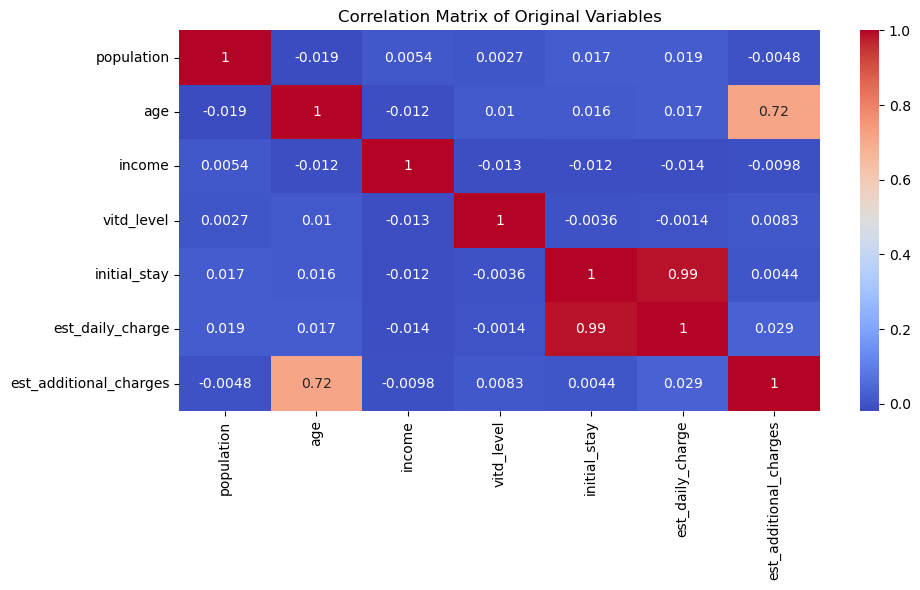

In [2]:
#Establish X and y
X = pca_df.drop('readmis_within_month', axis =1)
y = pca_df['readmis_within_month'].map({'Yes': 1, 'No': 0})

import matplotlib.pyplot as plt
import seaborn as sns

# Generate correlation matrix to assess linear relationships and multicollinearity
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Original Variables')
plt.tight_layout()
plt.show()

The correlation matrix shown above indicates that the provided data is not well-suited for PCA, as most values are well below the cutoff of 0.3. The only two relationships of note are between initial_stay and est_daily_charge (0.99), which is very high and indicates strong multicollinearity, and between est_additional_charges and age (0.72), which shows a moderate positive correlation. Based on this result, a potentially better choice for this data is t-Distributed Stochastic Neighbor Embedding (t-SNE), as it is a dimensionality reduction technique designed for non-linear relationships. t-SNE is more computationally intensive, but might provide more reliable results for this data. That said, we will proceed with PCA for now and keep this limiting factor in mind when reviewing our results ("Difference between PCA VS t-SNE," 2025). 

### C1: Variables

The continuous variables I will use for this PCA are as follows, with definitions from the medical dataset dictionary:


**Population (population):** Population within a mile radius of the patient, based on census data

**Age (age):** Age of the patient as reported in admissions information

**Income (income):** Annual income of the patient (or primary insurance holder) as reported at the time of admission

**VitD_levels (vitd_level):** The patient's vitamin D levels as measured in ng/ml

**Initial_days (initial_stay):** The number of days the patient stayed in the hospital during the initial visit

**Total Charge (est_daily_charge):** The amount charged ot the patient daily. This value reflects an average per patient, calculated as the total charge divided by the number of days hospitalized. This amount demonstrates typical charges billed to patients, excluding specialized treatments. 

**Additional Charges (est_additional_charges):** The average amount charged to the patient for miscellaneous procedures, treatments, medicines, anesthesiology, etc.

### C2: Standardization

In [3]:
from sklearn.preprocessing import StandardScaler

#Use the StandardScaler function to standardizee all values around a mean of 0 and a standard deviation of 1 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

#Print the new scaled dataset to verify changes
print(X_scaled_df.head())

   population       age    income  vitd_level  initial_stay  est_daily_charge  \
0   -0.473168 -0.024795  1.615914    0.583603     -0.907310         -0.727185   
1    0.090242 -0.121706  0.221443    0.483901     -0.734595         -0.513228   
2    0.482983 -0.024795 -0.915870    0.046227     -1.128292         -1.319983   
3   -0.526393  1.186592 -0.026263   -0.687811     -1.244503         -1.460517   
4   -0.315586 -1.526914 -1.377325   -0.260366     -1.261991         -1.467285   

   est_additional_charges  
0                0.765005  
1                0.715114  
2                0.698635  
3                0.009004  
4               -1.408991  


In [4]:
X_scaled_df.to_csv('D212_PA2_continuous_scaled.csv', index=False)

### D1: PCA Matrix

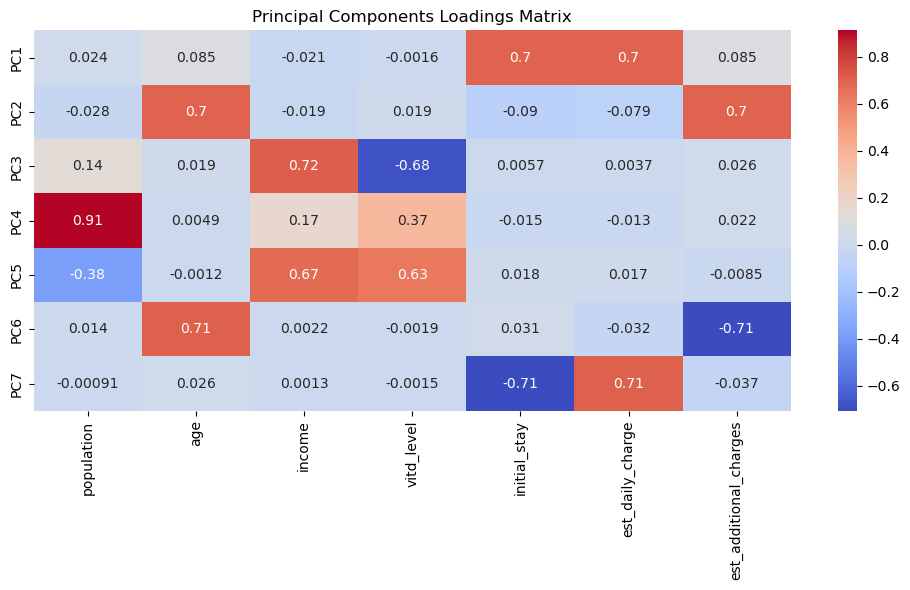

In [5]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

#Establish components for PCA matrix
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)
components_df = pd.DataFrame( pca.components_, columns=X.columns, index=[f'PC{i+1}' for i in range(7)])

#Generate loadings matrix as a heatmap to visually observe how much each variable contributes to each principal component
plt.figure(figsize=(10, 6))
sns.heatmap(components_df, annot=True, cmap='coolwarm')
plt.title('Principal Components Loadings Matrix')
plt.tight_layout()
plt.show()

The PC Loadings Matrix demonstrates the following:

**PC1:** Patients with longer initial stays and higher daily charges dominate.

**PC2** Patients older in age and with higher estimated additional charges dominate.

**PC3** Patients with lower vitamin D levels and higher income dominate. 

**PC4** Patients with a high population within a mile radius dominate.

**PC5** Patients with moderate income and vitamin D levels dominate. 

**PC6** Patients older in age with low estimated additional charges dominate. 

**PC7** Patients with shorter initial stays and higher estimated daily charges dominate.

### D2: Total Principal Components

To reduce the seven principal components, I generated a scree plot and printed the associated eigenvalues for each principal component, with a superimposed line at 1.0, as per the Kaiser Criterion (Mangale, 2020). Ensuring that all retained principal components have an eigenvalue of at least 1.0 ensures that the component contains at least the same amount of information as a single variable (Preacher & MacCallum, 2003, p. 22). To make the scree plot very visually interpretable, I largely followed the design shown in "Data-Driven MMA Outcome Prediction Enhanced by Fighter Styles: A Machine Learning Approach" and only went one step further by printing out the actual value of each eigenvalue as the eigenvalue for PC5 (0.9841) was very close to 1 and not as easily distinguishable from the cutoff line (Yin, 2024, p. 348). 

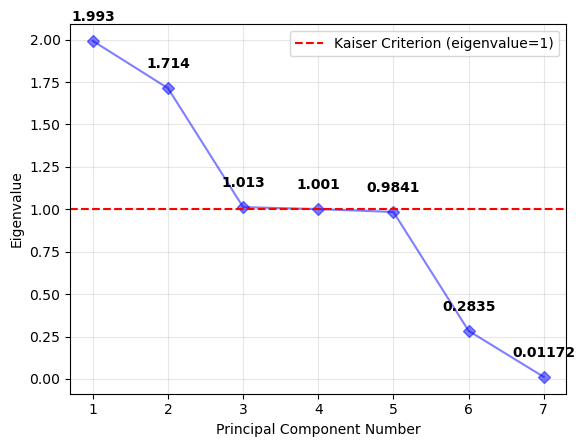

In [6]:
#Establish cov_matrix and eigenvalues
cov_matrix = np.dot(X_scaled.T, X_scaled) / X_scaled.shape[0]
eigenvalues = [np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector)) for eigenvector in pca.components_]

#Generate scree plot with printed eigenvalues and line for kaiser criterion at eigenvalue 1.0
plt.plot(range(1, 8), eigenvalues, 'bD-', alpha=0.5)
for i, eigenval in enumerate(eigenvalues, start=1):
    plt.text(i, eigenval + 0.1, f'{eigenval:.4}', ha='center', va='bottom', fontweight='bold')
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Criterion (eigenvalue=1)')
plt.xlabel('Principal Component Number')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, 8))
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.show() 

This scree plot indicates that PC1-PC4 should be retained for further analysis as they have eigenvalues above 1.0 (ranging from 1.91 to 1.02), while PC5-PC7 should be eliminated as their eigenvalues fall below the threshold.

### D3: Variance of each Component

In [7]:
#Calculating the individual contribution of each principal component to the variance in patient readmission
pc_contributions = list(pca.explained_variance_ratio_[:7])
pc_reduced = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']
for i in range(len(pc_reduced)):
    print(f"For {pc_reduced[i]}, the contribution is {round(pc_contributions[i] * 100, 3)}%")

For PC1, the contribution is 28.467%
For PC2, the contribution is 24.485%
For PC3, the contribution is 14.467%
For PC4, the contribution is 14.304%
For PC5, the contribution is 14.059%
For PC6, the contribution is 4.051%
For PC7, the contribution is 0.167%


### D4: Total Variance

In [8]:
#Calculating the combined contribution of the identified principal components (with PC5)
n_selected = 5
total_variance = sum(pca.explained_variance_ratio_[:n_selected]) * 100

print(f"{n_selected} principal components explain {round(total_variance, 3)}% of variance.")

#Calculating the combined contribution of the identified principal components (without PC5)
n_selected = 4
total_variance = sum(pca.explained_variance_ratio_[:n_selected]) * 100

#Print total variance scores
print(f"{n_selected} principal components explain {round(total_variance, 3)}% of variance.")

5 principal components explain 95.782% of variance.
4 principal components explain 81.723% of variance.


Although I previously used the Kaiser Criterion to easily indicate which principal components to keep and which to discard, I decided to further investigate how retaining that fifth principal component with an eigenvalue of 0.9841 would affect total variance capture compared to just four principal components. Since the fifth component was so close to the cut-off, I wanted to see how much information loss or retention would be observed from including it in the final analysis. The results show that five principal components explain about 95.782% of the variance, while four principal components explain about 81.723% of the variance. 

The fifth principal component alone accounts for about 14.059% of the total variance. While this is substantial, retaining five of seven variables represents minimal dimension reduction. Ultimately, the four principal components already capture a significant majority of the variance, so I will keep the reduced number of components to four and proceed with n=4 principal components for the remaining analysis. 

### D5: Analysis Results

Since we are trying to predict a binary outcome of whether or not a patient was readmitted within the same month as their initial visit, I opted to use a binomial logistic regression classification model to assess the performance of my principal component data. Logistic regression assumes that there is no multicollinearity in the data, which PCA explicitly addresses by transforming correlated variables into orthogonal (perfectly uncorrelated) principal components.

To measure the efficacy of the logistic regression model, I will generate four separate metrics: the **accuracy score**, which divides the number of correct predictions by total predictions to see how many predictions were correct; the **Receiver Operating Characteristic Area Under Curve (ROC-AUC)** score, which maps the relationship between the true positive rate and false positive rate across different cut-off thresholds; the **precision score**, which measures the proportion of predicted readmissions that were actually correct; and the **recall score**, which measures the model's sensitivity to correctly identify actual readmissions. In all cases, higher values indicate better performance, with ROC-AUC values above 0.9 considered outstanding (Singh, 2023).

Additionally, I will generate a confusion matrix and print the associated true and false positive/negative rates to visually demonstrate how often the logistic regression model is able to accurately predict patient readmission and how often it misses the mark ("Understanding the confusion matrix in machine learning," 2025). To complement the ROC-AUC score, I will also plot the ROC curve of the model, which graphically presents the trade-off between sensitivity (true positive rate) and specificity (false positive rate) ("AUC ROC curve in machine learning," 2025). 

Test Accuracy: 0.9743

ROC AUC score: 0.9979

Precision: 0.9617

Recall (Sensitivity): 0.9662

Confusion Matrix:
True Negatives: 1893 (63.10%)
False Positives: 41 (1.37%)
False Negatives: 36 (1.20%)
True Positives: 1030 (34.33%)


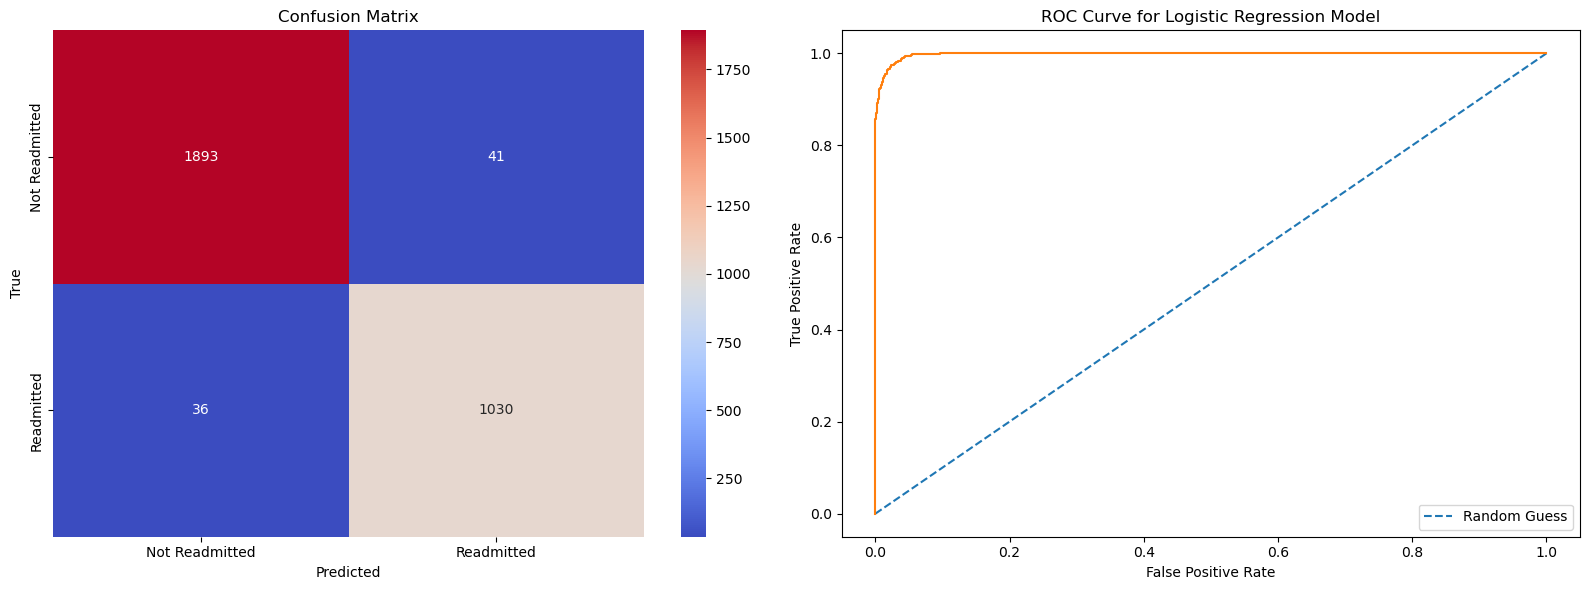

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

#Establish reduced principal components
n_components = 4
X_pca_reduced = X_pca[:, :n_components]

#Establish training and testing data split
X_train, X_test, y_train, y_test = train_test_split(X_pca_reduced, y, test_size=0.3, random_state=42)
class_labels = ['Not Readmitted', 'Readmitted']

#Train Logistic Regression model
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

#Make predictions
y_pred = log_model.predict(X_test)
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

#Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
final_matrix = confusion_matrix(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Test Accuracy: {test_accuracy:.4f}\n')
print(f'ROC AUC score: {roc_auc:.4f}\n')
print(f'Precision: {precision:.4f}\n')
print(f'Recall (Sensitivity): {recall:.4f}\n')

#Generate confusion matrix and AUC plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Generate Confusion Matrix
sns.heatmap(final_matrix, annot=True,fmt='d',cmap='coolwarm', xticklabels=class_labels, yticklabels=class_labels, ax = axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

#Print confusion matrix numbers for readability, with percentages
print("Confusion Matrix:")
total = final_matrix.sum()
print(f"True Negatives: {final_matrix[0,0]} ({final_matrix[0,0]/total*100:.2f}%)")
print(f"False Positives: {final_matrix[0,1]} ({final_matrix[0,1]/total*100:.2f}%)")
print(f"False Negatives: {final_matrix[1,0]} ({final_matrix[1,0]/total*100:.2f}%)")
print(f"True Positives: {final_matrix[1,1]} ({final_matrix[1,1]/total*100:.2f}%)")

#Plot ROC curve
axes[1].plot([0, 1], [0, 1], linestyle='--', label='Random Guess')
axes[1].plot(fpr, tpr)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve for Logistic Regression Model')
axes[1].legend(loc='lower right')

#Generate plots
plt.tight_layout()
plt.show()

The results show that the logistic regression model performed very well on the PCA data, achieving an accuracy of over 97%, an ROC-AUC score of over 99%, and precision and recall scores both over 96%. Meanwhile, the confusion matrix broke down this accuracy into more meaningful prediction numbers, showing that the model accurately predicted patient readmission 1,030 times (34.33%) and non-readmission 1,893 times (63.10%). Meanwhile, the ROC curve distinctly hugs the top-left corner and is far from the dashed "Random Guess" line, indicating the model is very good at making correct predictions.

This model shows that PCA may provide greater practical value to the hospital than I initially hoped, as it successfully identifies almost 97% of patients at risk for readmission within 30 days. However, one of the major drawbacks of PCA, since it substantially transforms the data, is that the model cannot explain which specific characteristics drive individual predictions. For immediate practical effects, the hospital administration might integrate the model as a screening tool to identify high-risk patients who should receive standardized enhanced discharge and/or follow-up care. Meanwhile, the data analysis team can return to the original data to identify patterns among high-risk patients, using such strategies as decision trees, clustering models, or additional logistic regression on the original seven variables. Without understanding the "why" behind patient readmission, stopping here would be equivalent to addressing symptoms without understanding root causes. By tying this result back to the original characteristics of all flagged patients, the hospital can identify the actual patterns driving readmissions and develop targeted intervention strategies.

### E1: Code References

Anello, E. (2021, December 10). Implementing PCA from scratch. Towards Data Science.                                                                    <br>                                                                    
https://towardsdatascience.com/implementing-pca-from-scratch-ea3970714d2b/

Arya, N. (2022, October 13). Classification metrics walkthrough: Logistic regression with accuracy, precision, recall, and ROC. KDnuggets.              
<br>
https://www.kdnuggets.com/2022/10/classification-metrics-walkthrough-logistic-regression-accuracy-precision-recall-roc.html

AUC ROC curve in machine learning. (2025, October 29). GeeksforGeeks.                                                                                   
<br>
https://www.geeksforgeeks.org/machine-learning/auc-roc-curve/

Feature importance in PCA: Analyzing loadings and Biplots. (2025, September 13). GeeksforGeeks.                                                         
<br>
https://www.geeksforgeeks.org/machine-learning/feature-importance-in-pca-analyzing-loadings-and-biplots/

Heatmap of correlation matrix. (n.d.). CodeSignal.                                                                                                      
<br>
https://codesignal.com/learn/courses/feature-engineering-and-correlation-analysis-in-pandas/lessons/heatmap-of-correlation-matrix

Mastering PCA: Eigenvectors, eigenvalues, and covariance matrix explained. (n.d.). CodeSignal Learn.                                                    
<br>
https://codesignal.com/learn/courses/navigating-data-simplification-with-pca/lessons/mastering-pca-eigenvectors-eigenvalues-and-covariance-matrix-explained

Principal component analysis with Python. (2025, July 11). GeeksforGeeks.                                                                               
<br>
https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-with-python/

StandardScaler. (2025, November 7). scikit-learn.                                                                                                       
<br>
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html                                                             

Understanding the confusion matrix in machine learning. (2025, May 30). GeeksforGeeks.                                                                  
<br>
https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/

### F1: Source References

AUC ROC curve in machine learning. (2025, October 29). GeeksforGeeks.                                                                                   
<br>
https://www.geeksforgeeks.org/machine-learning/auc-roc-curve/


Connelly, B. (2011, May 11). Principal component analysis (PCA) for dummies. Bill Connelly | Lab Hacker.                                                
<br>
https://www.billconnelly.net/?p=697


Difference between PCA VS t-SNE. (2025, July 12). GeeksforGeeks.                                                                                        <br>                                                                                      
https://www.geeksforgeeks.org/machine-learning/difference-between-pca-vs-t-sne/                                                                         


Feature importance in PCA: Analyzing loadings and Biplots. (2025, September 13). GeeksforGeeks.                                                         
<br>
https://www.geeksforgeeks.org/machine-learning/feature-importance-in-pca-analyzing-loadings-and-biplots/


Goldfield, N. (2011). How important is it to identify avoidable hospital readmissions with certainty? Canadian Medical Association Journal, 183(7), E368-E369                                                                                                                                               
<br>
https://doi.org/10.1503/cmaj.110448


How to perform a principal components analysis (PCA) in SPSS statistics. (n.d.). Laerd Statistics.                                                      
<br>
https://statistics.laerd.com/spss-tutorials/principal-components-analysis-pca-using-spss-statistics.php


Mangale, S. (2020, August 28). Scree plot. Medium.                                                                                                      
<br>
https://sanchitamangale12.medium.com/scree-plot-733ed72c8608


Preacher, K. J., & MacCallum, R. C. (2003). Repairing Tom swift's electric factor analysis machine. Understanding Statistics, 2(1), 13-43.              
<br>
https://doi.org/10.1207/s15328031us0201_02


Principal components (pca) and exploratory factor analysis (efa) with spss. (n.d.). UCLA: Statistical Consulting Group.                                 
<br>
https://stats.oarc.ucla.edu/spss/seminars/efa-spss/


Principal Component Analysis (PCA) - Assumptions. (n.d.). Laerd Statistics.                                                                             
<br>
https://statistics.laerd.com/premium/spss/pca/pca-in-spss-7.php#correlation-matrix


Seo, J. D. (2023, February 3). Principal component analysis for dummies: Understanding without equations. Medium.                                       
<br>
https://medium.com/@jdseo/principal-component-analysis-for-dummies-understanding-without-equations-ab462566a75e


Singh, V. (2023, October 17). ROC-AUC vs accuracy: which metric is more important? Shiksha Online.                                                      
<br>
https://www.shiksha.com/online-courses/articles/roc-auc-vs-accuracy/


Understanding the confusion matrix in machine learning. (2025, May 30). GeeksforGeeks.                                                                  
<br>
https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/


What is principal component analysis (PCA)? (n.d.). IBM.                                                                                                
<br>
https://www.ibm.com/think/topics/principal-component-analysis


Whitfield, B. (2025, June 23). Principal component analysis (PCA): Explained step-by-step. Built In.                                                    
<br>
https://builtin.com/data-science/step-step-explanation-principal-component-analysis


Yin, J. (2024). Data-driven MMA outcome prediction enhanced by fighter styles: A machine learning approach. 2024 4th International Conference on Machine Learning and Intelligent Systems Engineering (MLISE), 346-351.                                                                                  
<br>
https://doi.org/10.1109/mlise62164.2024.10674447